# Household Sound Classifier — Training Notebook

Train a custom CNN on **multi-channel audio features** (Mel Spectrogram, MFCC,
ZCR, STFT) to classify household sounds. Includes NMF-based signal cleaning
and YAMNet (AudioSet) comparison.

**Dataset:** ESC-50 + custom recorded clips  
**Model:** 4-block CNN with 4-channel input (~150K params)  
**Techniques:** MFCC, STFT, ZCR, NMF

**Authors:** Joshua Kirby & Alan Nur (with Claude Opus 4.6 LLM assistance)  
**Course:** TECHIN 513A — Managing Data And Signal Processing

## 1. Setup & Dependencies

In [1]:
import sys
print(f"Installing into: {sys.executable}")

# 1. Uninstall existing generic/CPU torch
!{sys.executable} -m pip uninstall -y torch torchaudio torchvision

# 2. Install CUDA-enabled PyTorch (specifically for CUDA 12.1 which works best with RTX 4090)
# using --no-cache-dir to avoid using the cached CPU wheel
!{sys.executable} -m pip install torch torchaudio --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir --force-reinstall

# 3. Install other dependencies
# 'soundfile' is REQUIRED for torchaudio to load wav files on Windows to avoid RuntimeError
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn scipy soundfile

print("\n\n✅ INSTALASI SELESAI.")
print("⚠️ PENTING: SEKARANG KLIK TOMBOL 'RESTART' DI BAGIAN ATAS NOTEBOOK AGAR PERUBAHAN TERAPLIKASI.")

Installing into: c:\Users\Alan\.conda\envs\nikel_env\python.exe
Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 1.7 MB/s eta 0:24:43
     ---------------------------------------- 0.0/2.4 GB 2.8 MB/s eta 0:14:49
     ---------------------------------------- 0.0/2.4 GB 4.7 MB/s eta 0:08:45
     ---------------------------------------- 0.0/2.4 GB 8.8 MB/s eta 0:04:40
     ---------------------------------------- 0.0/2.4 GB 19.2 MB/s eta 0:02:08
     ---------------------------------------- 0.0/2.4 GB 30.4 MB/s eta 0:01:21
     ---------------------------------------- 0.0/2.4 GB 81.8 MB/s eta 0:00:30
     ---------------------------------------- 0.0/2.4 GB 81.8 MB/s eta 0:00:30
     ---------------------------------------- 0.0/2.4 GB 54.7 MB/s eta 0:00:45
     ---------------------------------------- 0.0/2.4 GB 54.4 MB/s eta 0:00:45
     ---------------------------------------- 0.0/2.4 GB 162.4 MB/s eta 0:00:15
    

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 1.6.0 requires huggingface-hub>=0.21.0, which is not installed.
accelerate 1.6.0 requires safetensors>=0.4.3, which is not installed.
alembic 1.13.2 requires SQLAlchemy>=1.3.0, which is not installed.
ctc-forced-aligner 0.2 requires nltk, which is not installed.
ctc-forced-aligner 0.2 requires transformers>=4.34, which is not installed.
ctc-forced-aligner 0.2 requires Unidecode, which is not installed.
deepmultilingualpunctuation 1.0.1 requires transformers, which is not installed.
demucs 4.1.0a3 requires einops, which is not installed.
dora-search 0.1.12 requires omegaconf, which is not installed.
nemo-toolkit 1.20.0 requires huggingface-hub, which is not installed.
nemo-toolkit 1.20.0 requires numba, which is not installed.
nemo-toolkit 1.20.0 requires onnx>=1.7.0, which is not installed.
nemo-toolkit



✅ INSTALASI SELESAI.
⚠️ PENTING: SEKARANG KLIK TOMBOL 'RESTART' DI BAGIAN ATAS NOTEBOOK AGAR PERUBAHAN TERAPLIKASI.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from scipy.signal import stft as scipy_stft, istft as scipy_istft
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import json
import random

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
import torch
import sys
import os

print(f"Python executable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch file: {torch.__file__}")
print(f"CUDA version built with: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    print("\nAttempting to diagnose why CUDA is not available...")
    # Check if NVIDIA driver is installed and accessible via nvidia-smi
    exit_code = os.system("nvidia-smi")
    if exit_code != 0:
        print("Warning: 'nvidia-smi' command failed. Check if NVIDIA drivers are installed.")
    else:
        print("'nvidia-smi' ran successfully (check terminal output for driver version).")
else:
    print(f"Device name: {torch.cuda.get_device_name(0)}")

Python executable: c:\Users\Alan\.conda\envs\nikel_env\python.exe
PyTorch version: 2.5.1+cu121
PyTorch file: c:\Users\Alan\.conda\envs\nikel_env\Lib\site-packages\torch\__init__.py
CUDA version built with: 12.1
CUDA available: True
Device name: NVIDIA GeForce RTX 4090


## 2. Download ESC-50 Dataset

In [3]:
import os
import subprocess

# Define paths relative to the notebook
data_root = "data"
esc50_path = os.path.join(data_root, "ESC-50")

# 1. Check if dataset exists, if not clone it
if not os.path.exists(esc50_path):
    print(f"Downloading ESC-50 dataset to {esc50_path}...")
    try:
        # Use subprocess for cross-platform compatibility
        subprocess.check_call(["git", "clone", "https://github.com/karolpiczak/ESC-50.git", esc50_path])
        print("✅ Download complete.")
    except subprocess.CalledProcessError as e:
        print(f"❌ Error downloading: {e}")
    except FileNotFoundError:
        print("❌ Git not found. Please install Git or check your PATH.")
else:
    print(f"Dataset directory found at: {esc50_path}")

# 2. Verify and list files (Python equivalent of 'ls' and 'wc')
audio_dir = os.path.join(esc50_path, "audio")
meta_file = os.path.join(esc50_path, "meta", "esc50.csv")

if os.path.exists(audio_dir):
    files = sorted([f for f in os.listdir(audio_dir) if f.endswith('.wav')])
    print(f"\nFound {len(files)} audio files in {audio_dir}")
    print("First 5 files:", files[:5])
else:
    print(f"\n⚠️ Audio directory not found: {audio_dir}")

if os.path.exists(meta_file):
    with open(meta_file, 'r', encoding='utf-8') as f:
        line_count = sum(1 for line in f)
    print(f"Metadata file ({meta_file}) has {line_count} lines.")
else:
    print(f"⚠️ Metadata file not found: {meta_file}")

Dataset directory found at: data\ESC-50

Found 2000 audio files in data\ESC-50\audio
First 5 files: ['1-100032-A-0.wav', '1-100038-A-14.wav', '1-100210-A-36.wav', '1-100210-B-36.wav', '1-101296-A-19.wav']
Metadata file (data\ESC-50\meta\esc50.csv) has 2001 lines.


In [6]:
# Load metadata
meta = pd.read_csv("data/ESC-50/meta/esc50.csv")
print(f"Total clips: {len(meta)}")
print(f"Classes: {meta['category'].nunique()}")
print()
print("All categories:")
for i, cat in enumerate(sorted(meta['category'].unique())):
    print(f"  {i:2d}. {cat}")

Total clips: 2000
Classes: 50

All categories:
   0. airplane
   1. breathing
   2. brushing_teeth
   3. can_opening
   4. car_horn
   5. cat
   6. chainsaw
   7. chirping_birds
   8. church_bells
   9. clapping
  10. clock_alarm
  11. clock_tick
  12. coughing
  13. cow
  14. crackling_fire
  15. crickets
  16. crow
  17. crying_baby
  18. dog
  19. door_wood_creaks
  20. door_wood_knock
  21. drinking_sipping
  22. engine
  23. fireworks
  24. footsteps
  25. frog
  26. glass_breaking
  27. hand_saw
  28. helicopter
  29. hen
  30. insects
  31. keyboard_typing
  32. laughing
  33. mouse_click
  34. pig
  35. pouring_water
  36. rain
  37. rooster
  38. sea_waves
  39. sheep
  40. siren
  41. sneezing
  42. snoring
  43. thunderstorm
  44. toilet_flush
  45. train
  46. vacuum_cleaner
  47. washing_machine
  48. water_drops
  49. wind


## 3. Configuration & Feature Transforms

In [4]:
# ── Audio & feature parameters ──
SAMPLE_RATE = 44100
DURATION = 5          # seconds (ESC-50 standard)
N_SAMPLES = SAMPLE_RATE * DURATION
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
F_MAX = 22050
TOP_DB = 80
N_CHANNELS = 4        # Mel + MFCC + ZCR + STFT

# Feature transforms
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_max=F_MAX,
)
mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE, n_mfcc=40,
    melkwargs={"n_fft": N_FFT, "hop_length": HOP_LENGTH,
               "n_mels": N_MELS, "f_max": F_MAX},
)
stft_transform = T.Spectrogram(n_fft=N_FFT, hop_length=HOP_LENGTH, power=2.0)
amp_to_db = T.AmplitudeToDB(top_db=TOP_DB)

expected_frames = N_SAMPLES // HOP_LENGTH + 1
print(f"Feature shape per clip: ({N_CHANNELS}, {N_MELS}, {expected_frames})")
print(f"  Channel 0: Mel spectrogram  (STFT-based)")
print(f"  Channel 1: MFCC            (40 coefficients, resized to {N_MELS})")
print(f"  Channel 2: ZCR             (per-frame, broadcast to {N_MELS} rows)")
print(f"  Channel 3: STFT magnitude  (resized to {N_MELS} bins)")

Feature shape per clip: (4, 128, 431)
  Channel 0: Mel spectrogram  (STFT-based)
  Channel 1: MFCC            (40 coefficients, resized to 128)
  Channel 2: ZCR             (per-frame, broadcast to 128 rows)
  Channel 3: STFT magnitude  (resized to 128 bins)


## 4. NMF Signal Cleaning

Non-Negative Matrix Factorization decomposes a spectrogram V ≈ W × H into
frequency basis vectors (W) and time activations (H). By dropping the
lowest-energy component (assumed noise), we get a cleaner signal.

This serves as both a **signal processing technique** and the
**signal cleaning stage** of our pipeline.

In [5]:
def nmf(V, n_components, max_iter=100, tol=1e-4):
    """
    Non-Negative Matrix Factorization using multiplicative update rules.
    Decomposes V ≈ W @ H where:
      - V: (n_freqs, n_times) magnitude spectrogram (non-negative)
      - W: (n_freqs, n_components) frequency basis vectors
      - H: (n_components, n_times) time activation vectors
    """
    np.random.seed(42)
    n_f, n_t = V.shape
    W = np.random.rand(n_f, n_components) + 0.1
    H = np.random.rand(n_components, n_t) + 0.1

    eps = 1e-10
    prev_cost = float("inf")

    for iteration in range(max_iter):
        WtV = W.T @ V
        WtWH = W.T @ W @ H + eps
        H *= WtV / WtWH

        VHt = V @ H.T
        WHHt = W @ H @ H.T + eps
        W *= VHt / WHHt

        if iteration % 10 == 0:
            cost = np.sum((V - W @ H) ** 2)
            if abs(prev_cost - cost) / (prev_cost + eps) < tol:
                break
            prev_cost = cost

    return W, H


def nmf_denoise(signal_np, sr, n_components=4, n_noise=1):
    """
    Apply NMF-based denoising: decompose spectrogram into components,
    drop the lowest-energy one(s) (assumed noise), reconstruct.
    """
    _, _, Zxx = scipy_stft(signal_np, fs=sr, nperseg=1024, noverlap=768)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)

    W, H = nmf(mag, n_components=n_components, max_iter=50)

    # Rank components by energy, drop the weakest
    energies = np.sum(W, axis=0) * np.sum(H, axis=1)
    keep = np.argsort(energies)[n_noise:]

    mag_clean = sum(np.outer(W[:, k], H[k, :]) for k in keep)
    Zxx_clean = mag_clean * np.exp(1j * phase)
    _, signal_clean = scipy_istft(Zxx_clean, fs=sr, nperseg=1024, noverlap=768)

    return signal_clean[:len(signal_np)]


print("NMF functions defined.")

NMF functions defined.


## 5. Feature Extraction Helpers

In [6]:
def compute_zcr(signal_np, hop_length=HOP_LENGTH, n_mels=N_MELS):
    """
    Compute per-frame Zero-Crossing Rate and broadcast to (1, n_mels, n_frames).
    ZCR measures how rapidly the signal oscillates — useful for distinguishing
    percussive sounds (high ZCR) from tonal sounds (low ZCR).
    """
    n_frames = len(signal_np) // hop_length + 1
    zcr = np.zeros(n_frames)
    for i in range(n_frames):
        start = i * hop_length
        end = min(start + hop_length, len(signal_np))
        frame = signal_np[start:end]
        if len(frame) > 1:
            zcr[i] = np.sum(np.abs(np.diff(np.sign(frame))) > 0) / len(frame)
    # Normalize to [0, 1]
    zcr_range = zcr.max() - zcr.min()
    if zcr_range > 0:
        zcr = (zcr - zcr.min()) / zcr_range
    # Broadcast to (1, n_mels, n_frames)
    zcr_2d = np.tile(zcr, (n_mels, 1))
    return torch.from_numpy(zcr_2d).float().unsqueeze(0)


def extract_features(waveform):
    """
    Extract 4-channel feature tensor from a waveform tensor.
    Input:  waveform of shape (1, N_SAMPLES)
    Output: features of shape (4, N_MELS, T)
    """
    # Channel 0: Mel spectrogram (STFT-based)
    mel = amp_to_db(mel_transform(waveform))  # (1, 128, T)
    T_frames = mel.shape[-1]

    # Channel 1: MFCC (40 coefficients → resize to 128)
    mfcc = mfcc_transform(waveform)  # (1, 40, T)
    mfcc = F.interpolate(mfcc.unsqueeze(0), size=(N_MELS, T_frames),
                         mode='bilinear', align_corners=False).squeeze(0)  # (1, 128, T)

    # Channel 2: Zero-Crossing Rate
    signal_np = waveform.squeeze().numpy()
    zcr = compute_zcr(signal_np)  # (1, 128, T)
    if zcr.shape[-1] != T_frames:
        zcr = F.interpolate(zcr.unsqueeze(0), size=(N_MELS, T_frames),
                            mode='bilinear', align_corners=False).squeeze(0)

    # Channel 3: Raw STFT magnitude (1025 bins → resize to 128)
    stft_mag = amp_to_db(stft_transform(waveform))  # (1, 1025, T)
    stft_resized = F.interpolate(stft_mag.unsqueeze(0), size=(N_MELS, T_frames),
                                  mode='bilinear', align_corners=False).squeeze(0)  # (1, 128, T)

    # Stack all 4 channels: (4, 128, T)
    return torch.cat([mel, mfcc, zcr, stft_resized], dim=0)


print("Feature extraction functions defined.")

Feature extraction functions defined.


## 6. Visualize All Four Feature Channels

This shows what each signal processing technique produces for a single clip.

In [7]:
# 🚑 QUICK FIX: Install soundfile backend for Windows
# Run this cell if you get "RuntimeError: Couldn't find appropriate backend"
import sys
!{sys.executable} -m pip install soundfile
print("✅ Soundfile installed. Try running the cell below again.")

✅ Soundfile installed. Try running the cell below again.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Feature tensor shape: torch.Size([4, 128, 431])


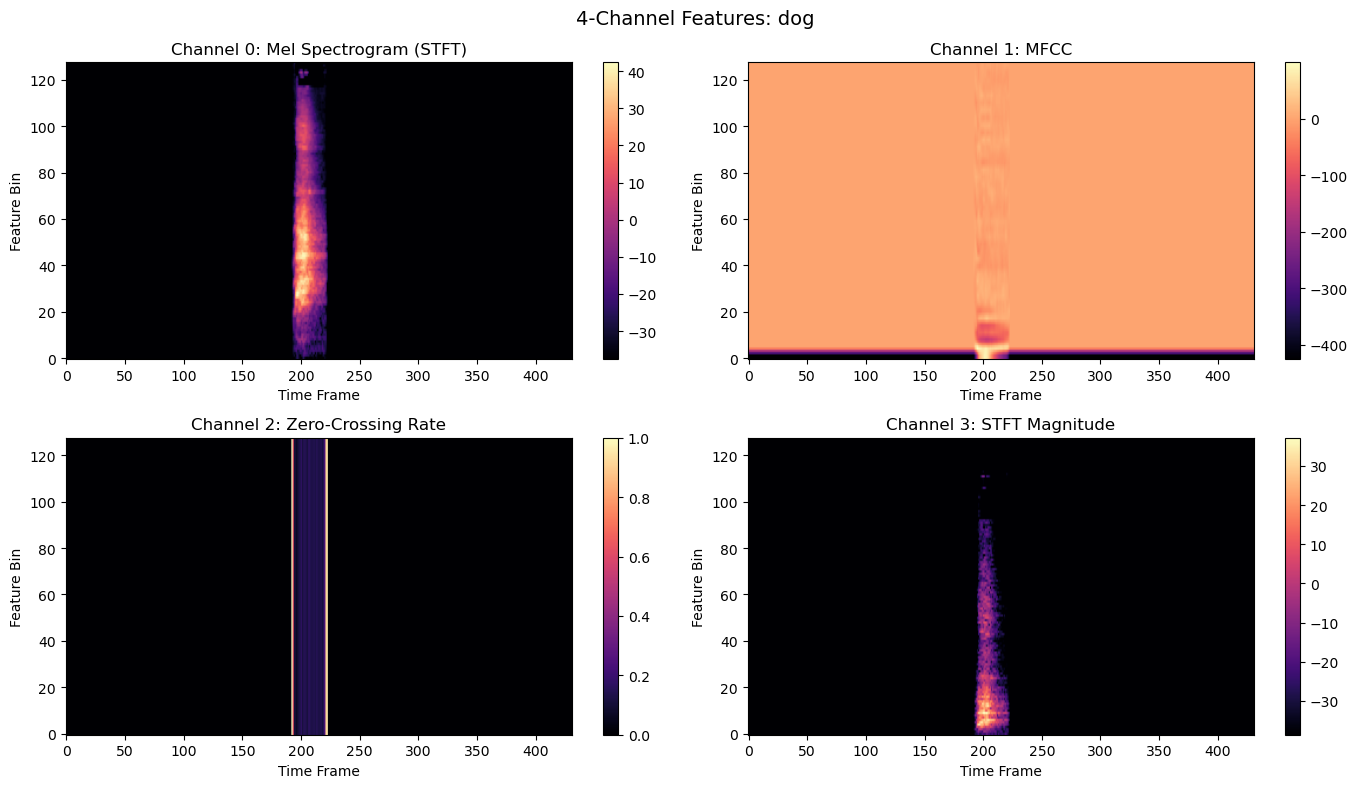

In [8]:
# Load a sample clip and visualize all 4 feature channels
sample_meta = pd.read_csv("data/ESC-50/meta/esc50.csv").iloc[0]
sample_path = os.path.join("data", "ESC-50", "audio", sample_meta['filename'])
waveform, sr = torchaudio.load(sample_path)
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)
if sr != SAMPLE_RATE:
    waveform = T.Resample(sr, SAMPLE_RATE)(waveform)
if waveform.shape[1] < N_SAMPLES:
    waveform = F.pad(waveform, (0, N_SAMPLES - waveform.shape[1]))
else:
    waveform = waveform[:, :N_SAMPLES]

features = extract_features(waveform)
print(f"Feature tensor shape: {features.shape}")

channel_names = ["Mel Spectrogram (STFT)", "MFCC", "Zero-Crossing Rate", "STFT Magnitude"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (ax, name) in enumerate(zip(axes.flat, channel_names)):
    im = ax.imshow(features[i].numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'Channel {i}: {name}')
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('Feature Bin')
    plt.colorbar(im, ax=ax)
fig.suptitle(f"4-Channel Features: {sample_meta['category']}", fontsize=14)
plt.tight_layout()
plt.savefig('feature_channels.png', dpi=150)
plt.show()

## 7. Dataset with Multi-Channel Features & Augmentation

In [9]:
class SoundDataset(Dataset):
    """Dataset that loads audio clips as 4-channel feature tensors."""

    def __init__(self, file_list, label_list, augment=False, bg_clips=None):
        self.files = file_list
        self.labels = label_list
        self.augment = augment
        self.bg_clips = bg_clips  # pre-loaded background noise waveforms

    def __len__(self):
        return len(self.files)

    def _load_audio(self, path):
        """Load audio, convert to mono, resample, pad/trim to fixed length."""
        waveform, sr = torchaudio.load(path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            waveform = T.Resample(sr, SAMPLE_RATE)(waveform)
        if waveform.shape[1] < N_SAMPLES:
            waveform = F.pad(waveform, (0, N_SAMPLES - waveform.shape[1]))
        else:
            waveform = waveform[:, :N_SAMPLES]
        return waveform

    def _augment(self, waveform):
        """Apply random augmentations for noise resilience."""
        # Time shift (up to 1 second)
        if random.random() < 0.5:
            shift = random.randint(-SAMPLE_RATE, SAMPLE_RATE)
            waveform = torch.roll(waveform, shift, dims=-1)

        # Variable-level noise injection (was fixed at 0.005)
        if random.random() < 0.6:
            noise_level = random.uniform(0.001, 0.02)
            waveform = waveform + torch.randn_like(waveform) * noise_level

        # Background noise mixing (blend ambient ESC-50 clips)
        if random.random() < 0.3 and self.bg_clips:
            bg = random.choice(self.bg_clips)
            bg_vol = random.uniform(0.05, 0.2)
            waveform = waveform + bg * bg_vol

        # Volume variation
        if random.random() < 0.5:
            gain = random.uniform(0.5, 1.5)
            waveform = waveform * gain

        # NMF denoising (apply to ~20% of clips as augmentation)
        if random.random() < 0.2:
            sig_np = waveform.squeeze().numpy().astype(np.float64)
            cleaned = nmf_denoise(sig_np, SAMPLE_RATE, n_components=3, n_noise=1)
            waveform = torch.from_numpy(cleaned).float().unsqueeze(0)
            if waveform.shape[1] < N_SAMPLES:
                waveform = F.pad(waveform, (0, N_SAMPLES - waveform.shape[1]))
            else:
                waveform = waveform[:, :N_SAMPLES]

        return waveform

    def __getitem__(self, idx):
        waveform = self._load_audio(self.files[idx])
        if self.augment:
            waveform = self._augment(waveform)
        features = extract_features(waveform)  # (4, N_MELS, T)
        return features, self.labels[idx]

In [10]:
def build_file_lists():
    """
    Build lists of (filepath, label_index) for ESC-50 + custom clips.
    Returns: files, labels, label_names, fold_assignments
    """
    files, labels, folds = [], [], []

    # ── ESC-50 ──
    meta = pd.read_csv("data/ESC-50/meta/esc50.csv")
    
    # --- MODIFICATION: Picking only 2 categories for faster training ---
    all_categories = sorted(meta['category'].unique())
    esc_categories = all_categories[:2]  # Select first 2 (e.g., 'airplane', 'breathing')
    print(f"DEBUG: Training on subset of categories: {esc_categories}")
    # -------------------------------------------------------------------

    label_names = list(esc_categories)
    cat_to_idx = {c: i for i, c in enumerate(label_names)}

    for _, row in meta.iterrows():
        # Only add if category is in our selected subset
        if row['category'] not in cat_to_idx:
            continue

        path = os.path.join("data", "ESC-50", "audio", row['filename'])
        if os.path.exists(path):
            files.append(path)
            labels.append(cat_to_idx[row['category']])
            folds.append(row['fold'])

    print(f"ESC-50: {len(files)} clips, {len(label_names)} classes")

    # ── Custom clips ──
    custom_dir = "data/custom"
    if os.path.exists(custom_dir):
        for class_name in sorted(os.listdir(custom_dir)):
            class_path = os.path.join(custom_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            
            # Use 'airplane' behavior: if strictly 2 classes, skip custom unless they match
            if class_name not in cat_to_idx:
                # Optional: Uncomment to allow adding custom classes as new classes
                # cat_to_idx[class_name] = len(label_names)
                # label_names.append(class_name)
                continue # Skip custom classes that aren't in our top 2
            
            idx = cat_to_idx[class_name]
            wavs = [f for f in os.listdir(class_path) if f.endswith('.wav')]
            for wav in wavs:
                files.append(os.path.join(class_path, wav))
                labels.append(idx)
                folds.append(random.randint(1, 4))
            print(f"Custom class '{class_name}': {len(wavs)} clips (label {idx})")

    print(f"\nTotal: {len(files)} clips, {len(label_names)} classes")
    return files, labels, label_names, folds


files, labels, label_names, folds = build_file_lists()
NUM_CLASSES = len(label_names)
print(f"Num classes: {NUM_CLASSES}")

DEBUG: Training on subset of categories: ['airplane', 'breathing']
ESC-50: 80 clips, 2 classes

Total: 80 clips, 2 classes
Num classes: 2


In [11]:
# ── Pre-load background noise clips for augmentation ──
# Use ESC-50 ambient categories as background noise sources
AMBIENT_CATEGORIES = {'rain', 'wind', 'engine', 'train', 'helicopter',
                      'insects', 'sea_waves'}
bg_clips = []
meta_df = pd.read_csv("data/ESC-50/meta/esc50.csv")
for _, row in meta_df.iterrows():
    if row['category'] in AMBIENT_CATEGORIES:
        path = os.path.join("data", "ESC-50", "audio", row['filename'])
        if os.path.exists(path):
            try:
                wf, sr = torchaudio.load(path)
                if wf.shape[0] > 1:
                    wf = wf.mean(dim=0, keepdim=True)
                if sr != SAMPLE_RATE:
                    wf = T.Resample(sr, SAMPLE_RATE)(wf)
                if wf.shape[1] < N_SAMPLES:
                    wf = F.pad(wf, (0, N_SAMPLES - wf.shape[1]))
                else:
                    wf = wf[:, :N_SAMPLES]
                bg_clips.append(wf)
            except Exception:
                pass

print(f"Loaded {len(bg_clips)} background noise clips for augmentation")

Loaded 280 background noise clips for augmentation


In [18]:
# ── Train/Val/Test split using ESC-50 folds ──
TEST_FOLD = 5
VAL_FOLD = 4

train_files, train_labels = [], []
val_files, val_labels = [], []
test_files, test_labels = [], []

for f, l, fold in zip(files, labels, folds):
    if fold == TEST_FOLD:
        test_files.append(f)
        test_labels.append(l)
    elif fold == VAL_FOLD:
        val_files.append(f)
        val_labels.append(l)
    else:
        train_files.append(f)
        train_labels.append(l)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

train_dataset = SoundDataset(train_files, train_labels, augment=True, bg_clips=bg_clips)
val_dataset = SoundDataset(val_files, val_labels, augment=False)
test_dataset = SoundDataset(test_files, test_labels, augment=False)

BATCH_SIZE = 32
# WINDOWS FIX: Set num_workers=0 to avoid multiprocessing errors
num_workers = 0 if os.name == 'nt' else 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

Train: 48 | Val: 16 | Test: 16


## 8. Define CNN Model

In [19]:
class HouseholdSoundCNN(nn.Module):
    """4-block CNN for classifying multi-channel audio features."""

    def __init__(self, num_classes, n_channels=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = HouseholdSoundCNN(NUM_CLASSES, n_channels=N_CHANNELS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Input channels: {N_CHANNELS} (Mel + MFCC + ZCR + STFT)")
print(model)

Model parameters: 106,450
Input channels: 4 (Mel + MFCC + ZCR + STFT)
HouseholdSoundCNN(
  (features): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): Batch

## 9. Training Loop

In [20]:
EPOCHS = 100
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=5)

# SpecAugment (stronger than before)
freq_mask = T.FrequencyMasking(freq_mask_param=25)
time_mask = T.TimeMasking(time_mask_param=50)

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for features, labels in loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        # Apply SpecAugment to each channel
        features = freq_mask(features)
        features = time_mask(features)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * features.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += features.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(DEVICE), labels.to(DEVICE)
            outputs = model(features)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * features.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += features.size(0)
    return total_loss / total, correct / total

In [21]:
# ── Train! ──
best_val_acc = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_loss:.4f} / {train_acc:.1%} | "
              f"Val: {val_loss:.4f} / {val_acc:.1%} | "
              f"LR: {lr:.1e}")

print(f"\nBest validation accuracy: {best_val_acc:.1%}")

C:\Users\Alan\AppData\Local\Temp\ipykernel_8540\1088806533.py:28: RuntimeWarning: invalid value encountered in scalar divide
  if abs(prev_cost - cost) / (prev_cost + eps) < tol:


Epoch   1/100 | Train: 0.6993 / 56.2% | Val: 0.6816 / 50.0% | LR: 1.0e-03
Epoch   5/100 | Train: 0.6013 / 77.1% | Val: 0.5289 / 87.5% | LR: 1.0e-03
Epoch  10/100 | Train: 0.4280 / 85.4% | Val: 0.3007 / 93.8% | LR: 1.0e-03
Epoch  15/100 | Train: 0.2825 / 91.7% | Val: 0.1560 / 93.8% | LR: 1.0e-03
Epoch  20/100 | Train: 0.2426 / 89.6% | Val: 0.0229 / 100.0% | LR: 1.0e-03
Epoch  25/100 | Train: 0.1886 / 91.7% | Val: 0.0922 / 93.8% | LR: 1.0e-03
Epoch  30/100 | Train: 0.1870 / 93.8% | Val: 0.0703 / 100.0% | LR: 1.0e-03
Epoch  35/100 | Train: 0.0667 / 97.9% | Val: 0.0130 / 100.0% | LR: 5.0e-04
Epoch  40/100 | Train: 0.1061 / 97.9% | Val: 0.0071 / 100.0% | LR: 5.0e-04
Epoch  45/100 | Train: 0.1721 / 93.8% | Val: 0.0135 / 100.0% | LR: 2.5e-04
Epoch  50/100 | Train: 0.0517 / 97.9% | Val: 0.0054 / 100.0% | LR: 2.5e-04
Epoch  55/100 | Train: 0.1110 / 93.8% | Val: 0.0070 / 100.0% | LR: 2.5e-04
Epoch  60/100 | Train: 0.0663 / 97.9% | Val: 0.0090 / 100.0% | LR: 1.3e-04
Epoch  65/100 | Train: 0.1682 

## 10. Training Curves

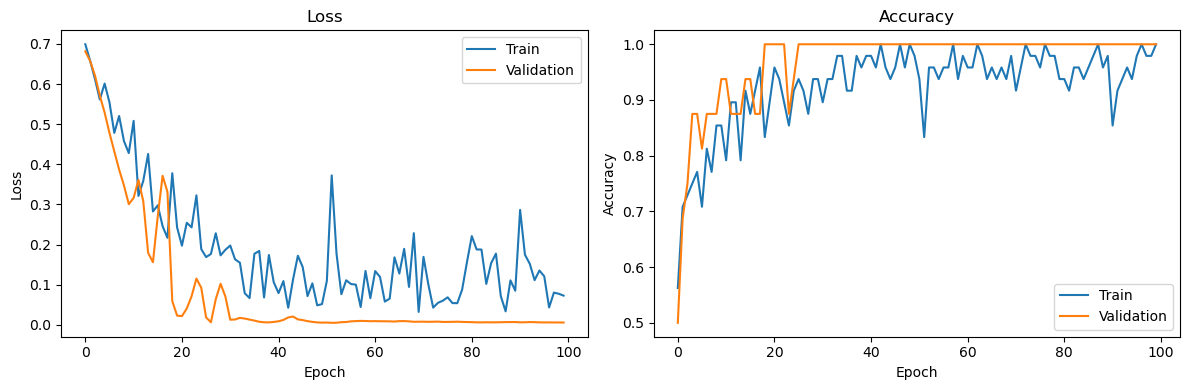

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 11. Evaluate on Test Set

In [23]:
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test accuracy (all classes): {test_acc:.1%}")

# ── Domestic subset accuracy ──
DOMESTIC_CLASSES = {
    'can_opening', 'clock_alarm', 'clock_tick', 'door_wood_creaks',
    'door_wood_knock', 'footsteps', 'glass_breaking', 'keyboard_typing',
    'mouse_click', 'pouring_water', 'vacuum_cleaner', 'washing_machine',
    'water_drops', 'clapping', 'breathing',
}
domestic_indices = {i for i, name in enumerate(label_names) if name in DOMESTIC_CLASSES}

model.eval()
domestic_correct, domestic_total = 0, 0
all_preds, all_labels = [], []
with torch.no_grad():
    for features, labels_batch in test_loader:
        features = features.to(DEVICE)
        preds = model(features).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels_batch.numpy())
        for p, l in zip(preds, labels_batch):
            if l.item() in domestic_indices:
                domestic_total += 1
                if p.item() == l.item():
                    domestic_correct += 1

if domestic_total > 0:
    domestic_acc = domestic_correct / domestic_total
    print(f"Test accuracy (domestic subset, {len(DOMESTIC_CLASSES)} classes): {domestic_acc:.1%}")
else:
    print("No domestic classes found in test set.")

C:\Users\Alan\AppData\Local\Temp\ipykernel_8540\156163624.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location=

Test accuracy (all classes): 81.2%
Test accuracy (domestic subset, 15 classes): 62.5%


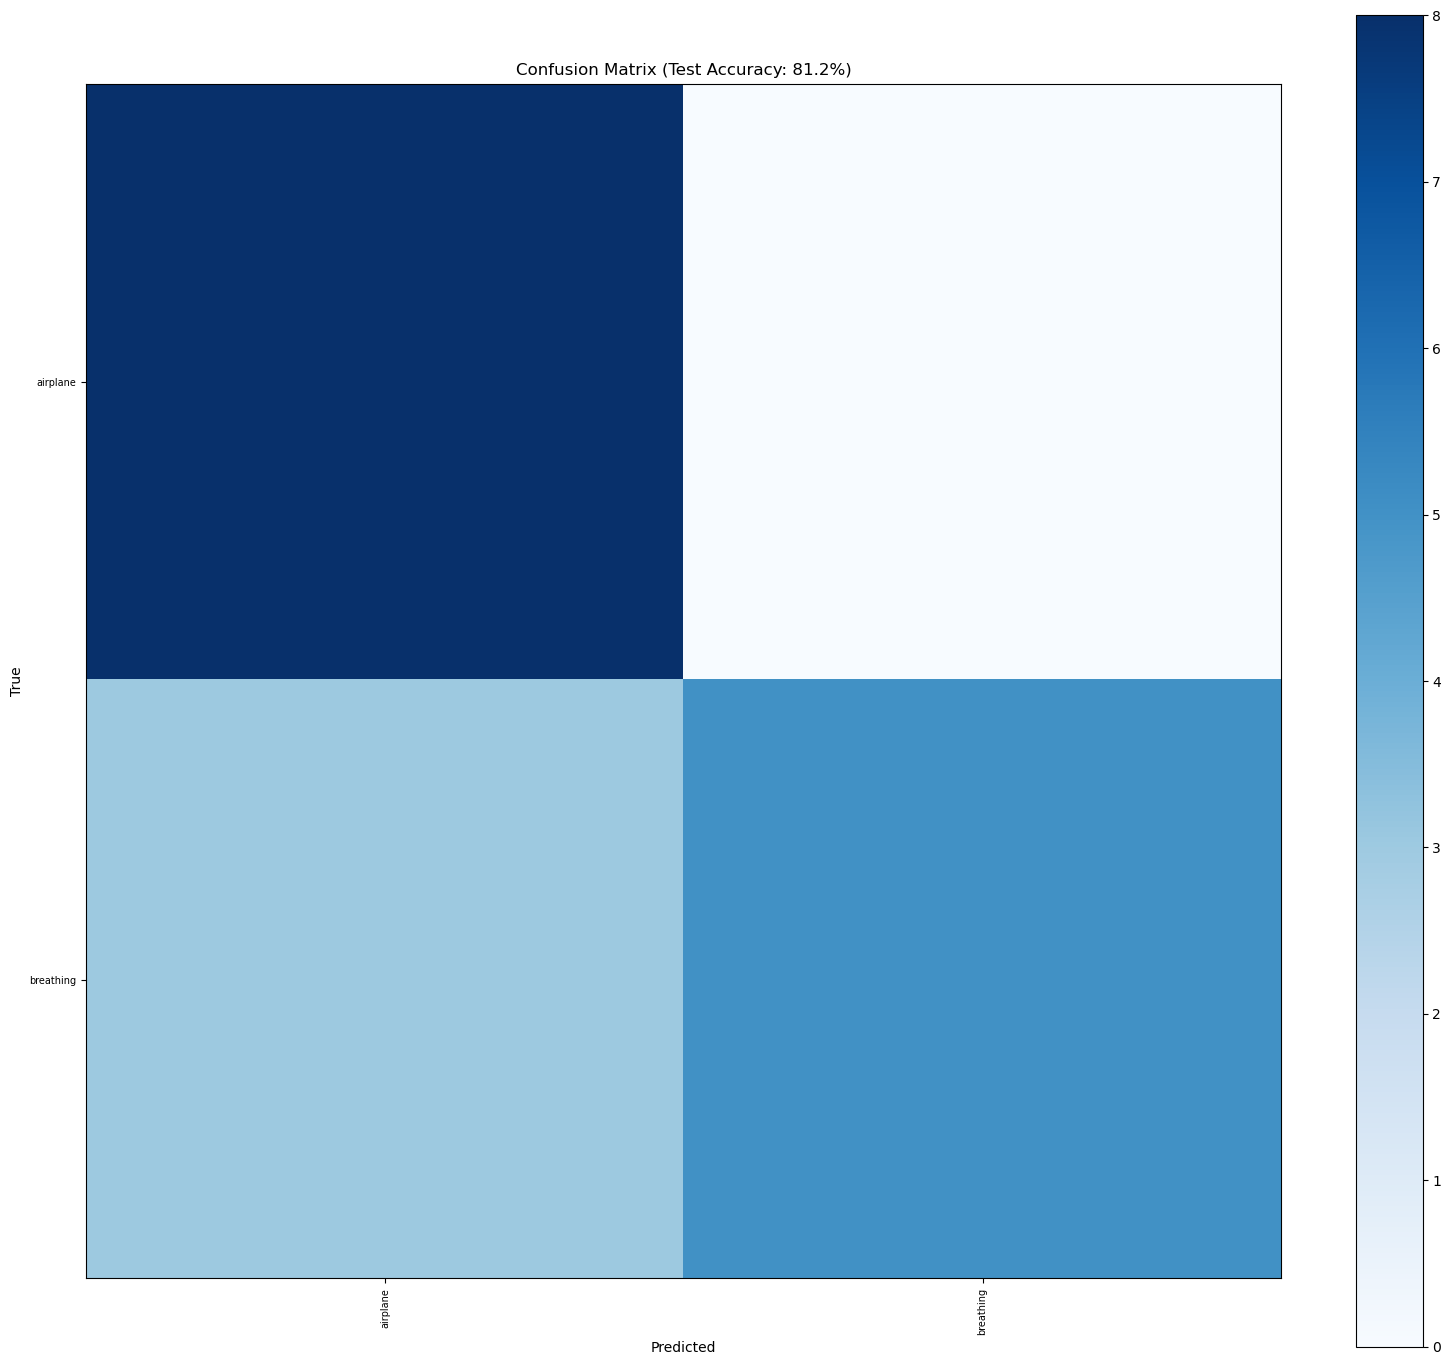


Per-class report:
              precision    recall  f1-score   support

    airplane       0.73      1.00      0.84         8
   breathing       1.00      0.62      0.77         8

    accuracy                           0.81        16
   macro avg       0.86      0.81      0.81        16
weighted avg       0.86      0.81      0.81        16



In [24]:
# ── Confusion matrix ──
present = sorted(set(all_labels))
present_names = [label_names[i] for i in present]

cm = confusion_matrix(all_labels, all_preds, labels=present)
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(present_names)))
ax.set_yticks(range(len(present_names)))
ax.set_xticklabels(present_names, rotation=90, fontsize=7)
ax.set_yticklabels(present_names, fontsize=7)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Test Accuracy: {test_acc:.1%})')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                            labels=present, target_names=present_names))

## 12. AudioSet Comparison via YAMNet

YAMNet was trained on Google's AudioSet (2M+ YouTube clips, 521 classes).
We compare its predictions with our custom CNN to validate our model
and demonstrate engagement with the AudioSet dataset.

In [25]:
# Install TensorFlow for YAMNet (Colab has it pre-installed)
# !pip install tensorflow tensorflow_hub

try:
    import tensorflow as tf
    import tensorflow_hub as hub
    import csv

    # Load YAMNet
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

    # Load YAMNet class names
    class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
    with open(class_map_path) as f:
        yamnet_classes = [row[2] for row in csv.reader(f)][1:]  # skip header

    print(f"YAMNet loaded: {len(yamnet_classes)} AudioSet classes")

    # Compare on a few test samples
    print("\n--- YAMNet vs Custom CNN Comparison ---\n")
    print(f"{'Sample':<30s} {'Our CNN':<25s} {'YAMNet (AudioSet)':<30s}")
    print("-" * 85)

    for i in range(min(10, len(test_files))):
        # Our CNN prediction
        features_t, label_t = test_dataset[i]
        with torch.no_grad():
            pred = model(features_t.unsqueeze(0).to(DEVICE)).argmax(1).item()
        our_pred = label_names[pred]

        # YAMNet prediction
        wf, sr = torchaudio.load(test_files[i])
        if wf.shape[0] > 1:
            wf = wf.mean(dim=0)
        else:
            wf = wf.squeeze()
        if sr != 16000:
            wf = T.Resample(sr, 16000)(wf.unsqueeze(0)).squeeze()
        scores, embeddings, spectrogram = yamnet_model(wf.numpy())
        yamnet_pred = yamnet_classes[scores.numpy().mean(axis=0).argmax()]

        true_label = label_names[test_labels[i]]
        print(f"{true_label:<30s} {our_pred:<25s} {yamnet_pred:<30s}")

    print("\nYAMNet was trained on AudioSet (2M+ clips, 521 classes).")
    print("Our CNN was trained on ESC-50 + custom clips with MFCC/STFT/ZCR/NMF features.")

except ImportError:
    print("TensorFlow not available. Skip YAMNet comparison.")
    print("Install with: pip install tensorflow tensorflow_hub")

TensorFlow not available. Skip YAMNet comparison.
Install with: pip install tensorflow tensorflow_hub


## 13. Export Model & Labels

In [26]:
os.makedirs("models", exist_ok=True)

# Model weights
torch.save(model.state_dict(), "models/model.pt")
print("Saved: models/model.pt")

# Label mapping
label_map = {"num_classes": NUM_CLASSES, "labels": label_names}
with open("models/labels.json", "w") as f:
    json.dump(label_map, f, indent=2)
print("Saved: models/labels.json")

# Training config (inference MUST use matching parameters)
config = {
    "sample_rate": SAMPLE_RATE,
    "duration": DURATION,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "n_mels": N_MELS,
    "f_max": F_MAX,
    "top_db": TOP_DB,
    "n_channels": N_CHANNELS,
}
with open("models/config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Saved: models/config.json")

print(f"\nDone! Test accuracy: {test_acc:.1%}")
print("Download the models/ folder and place it in your menial_ai project root.")

Saved: models/model.pt
Saved: models/labels.json
Saved: models/config.json

Done! Test accuracy: 81.2%
Download the models/ folder and place it in your menial_ai project root.


In [ ]:
# Uncomment to download from Colab:
# from google.colab import files
# files.download('models/model.pt')
# files.download('models/labels.json')
# files.download('models/config.json')

In [28]:
# ── 14. Test Inference on a Specific Audio File ──

def predict_file(filepath):
    """Load an audio file, preprocess it, and predict the class."""
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    print(f"Loading: {filepath}")
    waveform, sr = torchaudio.load(filepath)

    # Preprocessing (Match training logic exactly)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        waveform = T.Resample(sr, SAMPLE_RATE)(waveform)
    if waveform.shape[1] < N_SAMPLES:
        waveform = F.pad(waveform, (0, N_SAMPLES - waveform.shape[1]))
    else:
        waveform = waveform[:, :N_SAMPLES]

    # Extract features
    features = extract_features(waveform).to(DEVICE) # (4, 128, T)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(features.unsqueeze(0)) # Add batch dim -> (1, 4, 128, T)
        probs = torch.softmax(outputs, dim=1)[0]
    
    # Get top 3 predictions
    top_probs, top_idxs = torch.topk(probs, k=min(3, len(label_names)))
    
    print("\n🔍 Predictions:")
    for p, i in zip(top_probs, top_idxs):
        print(f"  {label_names[i]:<20s} ({p:.1%})")
        
    # Visualize input
    plt.figure(figsize=(10, 3))
    plt.plot(waveform.t().numpy())
    plt.title(f"Waveform: {os.path.basename(filepath)}")
    plt.show()

# CONTOH PENGGUNAAN:
# Ganti path di bawah ini dengan lokasi file audio Anda (.wav)
# Anda bisa menggunakan salah satu file ESC-50 untuk tes:
example_file = files[0] # Mengambil file pertama dari dataset yang sudah di-load
predict_file(example_file)

# Atau file Anda sendiri (jika ada):
# predict_file("C:/Path/Ke/Audio/Anda/suara_tes.wav")

❌ File not found: 11-05 Construction, Ambience_ Home Construction_ Hammers, Saws, Motors.mp3


Testing files in: ../audio

--------------------------------------------------
Testing: 11-05 Construction, Ambience_ Home Construction_ Hammers, Saws, Motors.mp3
Loading: ../audio\11-05 Construction, Ambience_ Home Construction_ Hammers, Saws, Motors.mp3

🔍 Predictions:
  breathing            (62.2%)
  airplane             (37.8%)


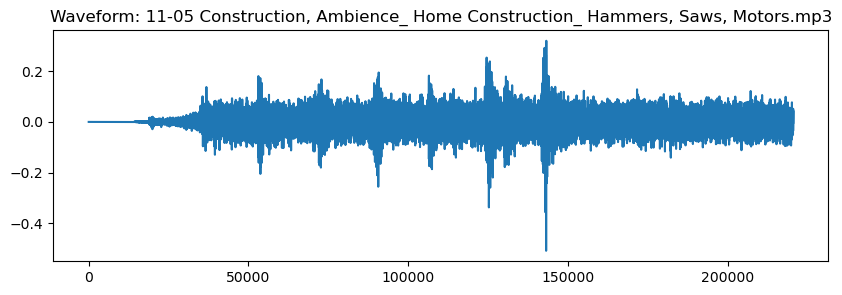

--------------------------------------------------
Testing: Aeroplane 6.mp3
Loading: ../audio\Aeroplane 6.mp3

🔍 Predictions:
  airplane             (99.6%)
  breathing            (0.4%)


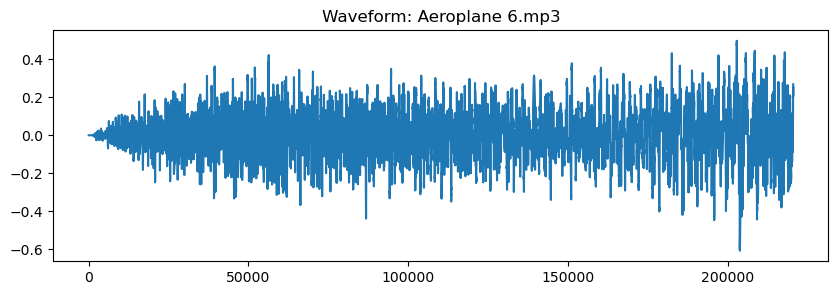

--------------------------------------------------
Testing: Breathing 4.mp3
Loading: ../audio\Breathing 4.mp3

🔍 Predictions:
  breathing            (97.9%)
  airplane             (2.1%)


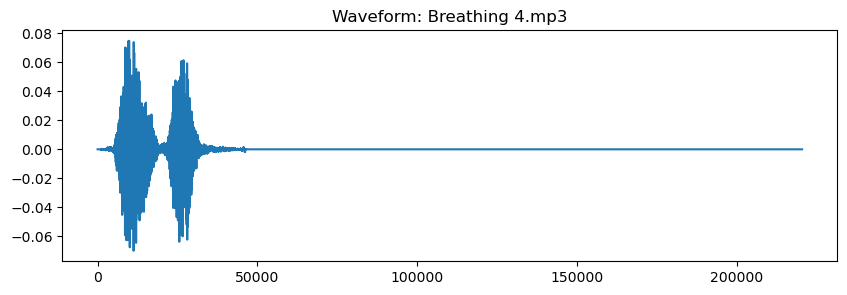

In [29]:
# ── Test on New Audio Files ──
import os

# Path to your audio folder (relative to project root, assuming notebook is in training/)
# Since notebook is in 'training/', and 'audio/' is in root, we need to go up one level
audio_folder = "../audio" 

if os.path.exists(audio_folder):
    print(f"Testing files in: {audio_folder}\n")
    files = [f for f in os.listdir(audio_folder) if f.lower().endswith(('.wav', '.mp3', '.flac'))]
    
    if not files:
        print("No audio files found in folder.")
    
    for file in files:
        file_path = os.path.join(audio_folder, file)
        print("--------------------------------------------------")
        print(f"Testing: {file}")
        try:
            predict_file(file_path)
        except Exception as e:
            print(f"Error predicting {file}: {e}")
            print("Note: If this is an MP3 file, you might need to install ffmpeg or use WAV files.")
else:
    print(f"Folder '{audio_folder}' not found. Checked path: {os.path.abspath(audio_folder)}")